# 3.6 DICOM Metadata Analysis: Scanner Effects on Predictions

This notebook analyzes DICOM metadata (manufacturer, model) to investigate:
1. **Scanner heterogeneity**: Which manufacturers/models are used?
2. **Subject-level scanner distribution**: Which subjects use which scanners?
3. **Scanner effects on predictions**: Do different scanners affect SBR predictions?
4. **Harmonization needs**: Are there systematic biases from different equipment?

## Research Questions:
- Do different scanner manufacturers produce different latent representations?
- Is there a scanner effect on SBR prediction accuracy?
- Should we harmonize or correct for scanner differences?
- Are certain latent dimensions more scanner-sensitive?

## Expected Outcomes:
- Identify scanner manufacturers and models in dataset
- Quantify scanner effects on model predictions
- Assess need for harmonization

## Section 1: Setup and Data Loading

### 1.1 Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score, KFold

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


### 1.2 Define Constants

In [2]:
# Feature columns
FEATURE_COLS = [f'latent_{i}' for i in range(256)]
TARGETS = ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']
SBR_COLS = [
    'DATSCAN_CAUDATE_R', 'DATSCAN_CAUDATE_L',
    'DATSCAN_PUTAMEN_R', 'DATSCAN_PUTAMEN_L',
    'DATSCAN_PUTAMEN_R_ANT', 'DATSCAN_PUTAMEN_L_ANT'
]

# Model parameters
ALPHA = 10.0
N_SPLITS = 5
RANDOM_STATE = 42

print(f"Features: {len(FEATURE_COLS)}")
print(f"Targets: {TARGETS}")

Features: 256
Targets: ['SBR_PC1', 'SBR_PC2', 'SBR_PC3']


### 1.3 Load DICOM Metadata

In [3]:
# Load DICOM metadata
df_dicom = pd.read_csv('data/csvData/dicom_metadata.csv')
print(f"DICOM metadata shape: {df_dicom.shape}")
print(f"\nColumns: {df_dicom.columns.tolist()}")
print(f"\nFirst few rows:")
print(df_dicom.head())

# Extract PATNO from file_path
def extract_patno_from_dicom_path(file_path):
    match = re.search(r'PPMI_Images_[^\\]+\\(\d+)', str(file_path))
    if match:
        return int(match.group(1))
    return None

df_dicom['PATNO'] = df_dicom['file_path'].apply(extract_patno_from_dicom_path)

print(f"\nPATNO extraction check:")
print(f"  Total rows: {len(df_dicom)}")
print(f"  Rows with PATNO: {df_dicom['PATNO'].notna().sum()}")
print(f"  Unique PATNOs: {df_dicom['PATNO'].nunique()}")

DICOM metadata shape: (2986, 6)

Columns: ['file_path', 'group', 'PatientSex', 'StudyDescription', 'Manufacturer', 'ManufacturerModelName']

First few rows:
                                           file_path group PatientSex  \
0  Images\PPMI_Images_PD\100001\Reconstructed_DaT...    PD          M   
1  Images\PPMI_Images_PD\100001\Reconstructed_DaT...    PD          M   
2  Images\PPMI_Images_PD\100001\Reconstructed_DaT...    PD          M   
3  Images\PPMI_Images_PD\100001\Reconstructed_DaT...    PD          M   
4  Images\PPMI_Images_PD\100001\Reconstructed_DaT...    PD          M   

  StudyDescription Manufacturer ManufacturerModelName  
0            1-DAT   SIEMENS NM               Encore2  
1          V02-DAT   SIEMENS NM               Encore2  
2        V04EI-DAT   SIEMENS NM               Encore2  
3        V05EI-DAT   SIEMENS NM               Encore2  
4            3-DAT   SIEMENS NM               Encore2  

PATNO extraction check:
  Total rows: 2986
  Rows with PATNO: 2986


### 1.4 Load Latent Vectors and Clinical Data

In [4]:
# Load merged clinical data
# df_merged = pd.read_csv('output/merged_data.csv')
# print(f"Merged clinical data: {df_merged.shape}")

# # Load latent vectors
# latent_file = 'output/Experiments/LatentVectorAnalysis/train_latent_vectors_with_patno.csv'
# df_latent = pd.read_csv(latent_file)
# print(f"Latent vectors: {df_latent.shape}")

# # Merge latent with clinical data
# df_latent_clean = df_latent.dropna(subset=['PATNO']).copy()
# df_combined = pd.merge(df_latent_clean, df_merged, on='PATNO', how='inner')
# print(f"Combined dataset: {df_combined.shape}")

df_combined = pd.read_csv('output/final_train_combined_vae_data.csv')

print(f"Combined dataset shape: {df_combined.shape}")
print(f"Unique patients in combined data: {df_combined['PATNO'].nunique()}")

# Check for multiple visits per patient
visits_per_patient = df_combined.groupby('PATNO').size()
print(f"\nVisits per patient statistics:")
print(visits_per_patient.describe())
print(f"Patients with multiple visits: {(visits_per_patient > 1).sum()}")

# Calculate SBR PCs
df_with_sbr = df_combined.dropna(subset=SBR_COLS).copy()
from sklearn.decomposition import PCA
scaler_sbr = StandardScaler()
sbr_scaled = scaler_sbr.fit_transform(df_with_sbr[SBR_COLS])
pca = PCA(n_components=3, random_state=0)
sbr_pcs = pca.fit_transform(sbr_scaled)
df_with_sbr['SBR_PC1'] = sbr_pcs[:, 0]
df_with_sbr['SBR_PC2'] = sbr_pcs[:, 1]
df_with_sbr['SBR_PC3'] = sbr_pcs[:, 2]
df_combined = df_with_sbr.copy()

# Select best visit per patient
# def select_best_visit(group):
#     valid_rows = group.dropna(subset=['AGE_AT_VISIT', 'SEX', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3'])
#     if len(valid_rows) == 0:
#         return None
#     if 'EVENT_ID' in valid_rows.columns:
#         priority = {'SC': 0, 'BL': 1, 'V01': 2, 'V02': 3}
#         valid_rows = valid_rows.copy()
#         valid_rows['priority'] = valid_rows['EVENT_ID'].map(priority).fillna(99)
#         return valid_rows.sort_values('priority').iloc[0:1]
#     return valid_rows.iloc[0:1]

# df_final = df_combined.groupby('PATNO', group_keys=False).apply(select_best_visit)
# df_final = df_final.dropna(subset=['PATNO']).reset_index(drop=True)

df_final = df_combined.dropna(subset=['PATNO']).reset_index(drop=True)

print(f"\nFinal dataset: {df_final.shape}")
print(f"Unique patients: {df_final['PATNO'].nunique()}")

Combined dataset shape: (2373, 303)
Unique patients in combined data: 1437

Visits per patient statistics:
count    1437.000000
mean        1.651357
std         0.955241
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         5.000000
dtype: float64
Patients with multiple visits: 553

Final dataset: (2373, 306)
Unique patients: 1437


### 1.5 Merge with DICOM Metadata

In [5]:
# Get most recent scan metadata for each patient
# df_dicom_latest = df_dicom.sort_values('file_path').drop_duplicates('PATNO', keep='last')

# # Merge with final dataset
# df_analysis = pd.merge(df_final, df_dicom_latest[['PATNO', 'Manufacturer', 'ManufacturerModelName']], 
#                         on='PATNO', how='left')

df_analysis = df_final.copy()

print(f"Analysis dataset: {df_analysis.shape}")
print(f"Rows with scanner metadata: {df_analysis['Manufacturer'].notna().sum()}")

# Display scanner distribution
print(f"\nScanner Manufacturers:")
print(df_analysis['Manufacturer'].value_counts())

print(f"\nScanner Models:")
print(df_analysis['ManufacturerModelName'].value_counts())

Analysis dataset: (2373, 306)
Rows with scanner metadata: 2372

Scanner Manufacturers:
Manufacturer
SIEMENS NM                              1173
GE MEDICAL SYSTEMS                       470
Marconi Medical Systems, NM Division     258
PICKER                                   130
Philips Nuclear Medicine                 101
Philips Healthcare                        63
Picker International, NM Division         59
GE_MEDICAL_SYSTEMS                        33
ADAC                                      25
0000000                                   22
Philips Medical Systems, NM Division      22
Mediso                                     6
GE MEDICAL SYSTEMS, NUCLEAR                4
MiE                                        3
Numa_Inc                                   2
PMOD Technologies                          1
Name: count, dtype: int64

Scanner Models:
ManufacturerModelName
Encore2                          933
P3000XP                          252
IP2                              214
INFI

## Section 2: Scanner Distribution Analysis

### 2.1 Scanner Coverage by Subject

In [6]:
print("\n" + "="*80)
print("SCANNER DISTRIBUTION ANALYSIS")
print("="*80)

# Summary statistics
print(f"\nTotal subjects: {len(df_analysis)}")
print(f"Subjects with scanner info: {df_analysis['Manufacturer'].notna().sum()}")
print(f"Subjects missing scanner info: {df_analysis['Manufacturer'].isna().sum()}")

# Manufacturer breakdown
print(f"\nManufacturer Breakdown:")
mfg_counts = df_analysis['Manufacturer'].value_counts()
for mfg, count in mfg_counts.items():
    pct = count / len(df_analysis) * 100
    print(f"  {mfg}: {count} subjects ({pct:.1f}%)")

# Model breakdown
print(f"\nModel Breakdown:")
model_counts = df_analysis['ManufacturerModelName'].value_counts()
for model, count in model_counts.items():
    pct = count / len(df_analysis) * 100
    print(f"  {model}: {count} subjects ({pct:.1f}%)")


SCANNER DISTRIBUTION ANALYSIS

Total subjects: 2373
Subjects with scanner info: 2372
Subjects missing scanner info: 1

Manufacturer Breakdown:
  SIEMENS NM: 1173 subjects (49.4%)
  GE MEDICAL SYSTEMS: 470 subjects (19.8%)
  Marconi Medical Systems, NM Division: 258 subjects (10.9%)
  PICKER: 130 subjects (5.5%)
  Philips Nuclear Medicine: 101 subjects (4.3%)
  Philips Healthcare: 63 subjects (2.7%)
  Picker International, NM Division: 59 subjects (2.5%)
  GE_MEDICAL_SYSTEMS: 33 subjects (1.4%)
  ADAC: 25 subjects (1.1%)
  0000000: 22 subjects (0.9%)
  Philips Medical Systems, NM Division: 22 subjects (0.9%)
  Mediso: 6 subjects (0.3%)
  GE MEDICAL SYSTEMS, NUCLEAR: 4 subjects (0.2%)
  MiE: 3 subjects (0.1%)
  Numa_Inc: 2 subjects (0.1%)
  PMOD Technologies: 1 subjects (0.0%)

Model Breakdown:
  Encore2: 933 subjects (39.3%)
  P3000XP: 252 subjects (10.6%)
  IP2: 214 subjects (9.0%)
  INFINIA: 191 subjects (8.0%)
  BrightView: 185 subjects (7.8%)
  HERMES Workstation: 130 subjects (5.5

### 2.2 Subject-Level Scanner Information

In [7]:
# Create summary table
scanner_summary = df_analysis[['PATNO', 'Manufacturer', 'ManufacturerModelName', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3']].copy()
scanner_summary = scanner_summary.dropna(subset=['Manufacturer'])
scanner_summary = scanner_summary.sort_values('Manufacturer')

print(f"\nSample of Subject-Level Scanner Information:")
print(scanner_summary.head(20).to_string(index=False))

# Statistics by manufacturer
print(f"\n" + "="*80)
print("SBR STATISTICS BY MANUFACTURER")
print("="*80)

for mfg in df_analysis['Manufacturer'].dropna().unique():
    mfg_data = df_analysis[df_analysis['Manufacturer'] == mfg]
    print(f"\n{mfg} (n={len(mfg_data)}):")
    for target in TARGETS:
        mean = mfg_data[target].mean()
        std = mfg_data[target].std()
        print(f"  {target}: mean={mean:.3f}, std={std:.3f}")


Sample of Subject-Level Scanner Information:
 PATNO Manufacturer ManufacturerModelName   SBR_PC1   SBR_PC2   SBR_PC3
  3058      0000000            BrightView -2.991283 -0.377569  0.135388
  3066      0000000            BrightView -0.968867 -0.508808  0.249140
  3061      0000000            BrightView  0.684768  1.084690  0.330846
  3077      0000000            BrightView -2.565419  0.186925 -0.804207
  3081      0000000            BrightView -0.733569 -0.115357  0.580497
  3072      0000000            BrightView  5.226821  0.343479 -0.438932
  3062      0000000            BrightView -1.659513 -0.501570 -0.048566
  3056      0000000            BrightView -2.200211  0.087076  0.043939
  3075      0000000            BrightView  1.380157 -0.230761 -0.565173
  3068      0000000            BrightView  0.688832  1.061912  0.355590
  3061      0000000            BrightView  0.238027  1.216030  0.185832
  3069      0000000            BrightView  4.088739  0.397053  0.917299
  3067      000000

## Section 3: Scanner Effects on Predictions

### 3.1 Compare Model Performance by Scanner

In [8]:
print("\n" + "="*80)
print("SCANNER EFFECTS ON MODEL PERFORMANCE")
print("="*80)

# Prepare data
df_scanner = df_analysis.dropna(subset=['Manufacturer']).copy()

# Extract features and targets
X = df_scanner[FEATURE_COLS].values
Y = df_scanner[TARGETS].values

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model on all data
kfold = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

results_by_scanner = []

for target_idx, target_name in enumerate(TARGETS):
    y = Y[:, target_idx]
    
    # Overall CV performance
    cv_scores = cross_val_score(Ridge(alpha=ALPHA), X_scaled, y, cv=kfold, scoring='r2')
    overall_r2 = cv_scores.mean()
    
    print(f"\n{target_name} - Overall CV R²: {overall_r2:.4f}")
    
    # Per-scanner performance
    for mfg in df_scanner['Manufacturer'].unique():
        mfg_mask = df_scanner['Manufacturer'] == mfg
        X_mfg = X_scaled[mfg_mask]
        y_mfg = y[mfg_mask]
        
        n_samples = len(y_mfg)
        
        if n_samples < 3:
            # Too few samples for meaningful evaluation
            print(f"  {mfg} (n={n_samples}): Skipped (insufficient samples for evaluation)")
            continue
        elif n_samples < N_SPLITS:
            # Not enough for full CV, use Leave-One-Out or simple train/test
            from sklearn.model_selection import LeaveOneOut
            loo = LeaveOneOut()
            cv_scores_mfg = cross_val_score(Ridge(alpha=ALPHA), X_mfg, y_mfg, cv=loo, scoring='r2')
            r2_mfg = cv_scores_mfg.mean()
            print(f"  {mfg} (n={n_samples}): R²={r2_mfg:.4f} [LOO-CV]")
        else:
            # Enough samples for full CV
            cv_scores_mfg = cross_val_score(Ridge(alpha=ALPHA), X_mfg, y_mfg, cv=min(N_SPLITS, n_samples), scoring='r2')
            r2_mfg = cv_scores_mfg.mean()
            print(f"  {mfg} (n={n_samples}): R²={r2_mfg:.4f}")
            
            results_by_scanner.append({
                'Target': target_name,
                'Manufacturer': mfg,
                'N_Subjects': n_samples,
                'R2_Score': r2_mfg
            })


SCANNER EFFECTS ON MODEL PERFORMANCE

SBR_PC1 - Overall CV R²: 0.9788
  SIEMENS NM (n=1173): R²=0.9771
  PICKER (n=130): R²=0.8841
  Philips Nuclear Medicine (n=101): R²=0.8115
  GE MEDICAL SYSTEMS (n=470): R²=0.9605
  GE_MEDICAL_SYSTEMS (n=33): R²=0.5621
  Marconi Medical Systems, NM Division (n=258): R²=0.9267
  Philips Healthcare (n=63): R²=0.4564
  Picker International, NM Division (n=59): R²=0.7035
  0000000 (n=22): R²=0.5743
  ADAC (n=25): R²=0.1444
  Philips Medical Systems, NM Division (n=22): R²=-1.9424
  GE MEDICAL SYSTEMS, NUCLEAR (n=4): R²=nan [LOO-CV]
  MiE (n=3): R²=nan [LOO-CV]
  Mediso (n=6): R²=nan
  PMOD Technologies (n=1): Skipped (insufficient samples for evaluation)
  Numa_Inc (n=2): Skipped (insufficient samples for evaluation)

SBR_PC2 - Overall CV R²: 0.8798
  SIEMENS NM (n=1173): R²=0.8877
  PICKER (n=130): R²=0.3953
  Philips Nuclear Medicine (n=101): R²=0.6436
  GE MEDICAL SYSTEMS (n=470): R²=0.7838
  GE_MEDICAL_SYSTEMS (n=33): R²=0.1118
  Marconi Medical Sy

### 3.2 Statistical Tests for Scanner Effects

In [9]:
print("\n" + "="*80)
print("STATISTICAL TESTS: SCANNER EFFECTS")
print("="*80)

# Test if SBR values differ significantly by manufacturer
for target in TARGETS:
    print(f"\n{target}:")
    
    # ANOVA test
    groups = []
    for mfg in df_scanner['Manufacturer'].unique():
        mfg_data = df_scanner[df_scanner['Manufacturer'] == mfg][target].values
        groups.append(mfg_data)
    
    f_stat, p_val = stats.f_oneway(*groups)
    print(f"  ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val:.4e}")
    
    if p_val < 0.05:
        print(f"  → Significant difference between manufacturers (p<0.05)")
    else:
        print(f"  → No significant difference between manufacturers (p≥0.05)")
    
    # Pairwise comparisons
    manufacturers = df_scanner['Manufacturer'].unique()
    if len(manufacturers) > 1:
        print(f"  Pairwise comparisons:")
        for i, mfg1 in enumerate(manufacturers):
            for mfg2 in manufacturers[i+1:]:
                data1 = df_scanner[df_scanner['Manufacturer'] == mfg1][target].values
                data2 = df_scanner[df_scanner['Manufacturer'] == mfg2][target].values
                t_stat, p_val_t = stats.ttest_ind(data1, data2)
                print(f"    {mfg1} vs {mfg2}: t={t_stat:.3f}, p={p_val_t:.4e}")


STATISTICAL TESTS: SCANNER EFFECTS

SBR_PC1:
  ANOVA F-statistic: 14.3384, p-value: 1.0698e-35
  → Significant difference between manufacturers (p<0.05)
  Pairwise comparisons:
    SIEMENS NM vs PICKER: t=-7.762, p=1.6763e-14
    SIEMENS NM vs Philips Nuclear Medicine: t=0.754, p=4.5105e-01
    SIEMENS NM vs GE MEDICAL SYSTEMS: t=-8.226, p=3.8912e-16
    SIEMENS NM vs GE_MEDICAL_SYSTEMS: t=-7.842, p=9.6874e-15
    SIEMENS NM vs Marconi Medical Systems, NM Division: t=-0.418, p=6.7566e-01
    SIEMENS NM vs Philips Healthcare: t=-1.302, p=1.9329e-01
    SIEMENS NM vs Picker International, NM Division: t=0.754, p=4.5121e-01
    SIEMENS NM vs 0000000: t=-1.248, p=2.1211e-01
    SIEMENS NM vs ADAC: t=-2.068, p=3.8842e-02
    SIEMENS NM vs Philips Medical Systems, NM Division: t=-6.878, p=9.8001e-12
    SIEMENS NM vs GE MEDICAL SYSTEMS, NUCLEAR: t=0.589, p=5.5630e-01
    SIEMENS NM vs MiE: t=0.185, p=8.5317e-01
    SIEMENS NM vs Mediso: t=-3.922, p=9.2767e-05
    SIEMENS NM vs PMOD Technolo

## Section 4: Visualizations

### 4.1 Scanner Distribution

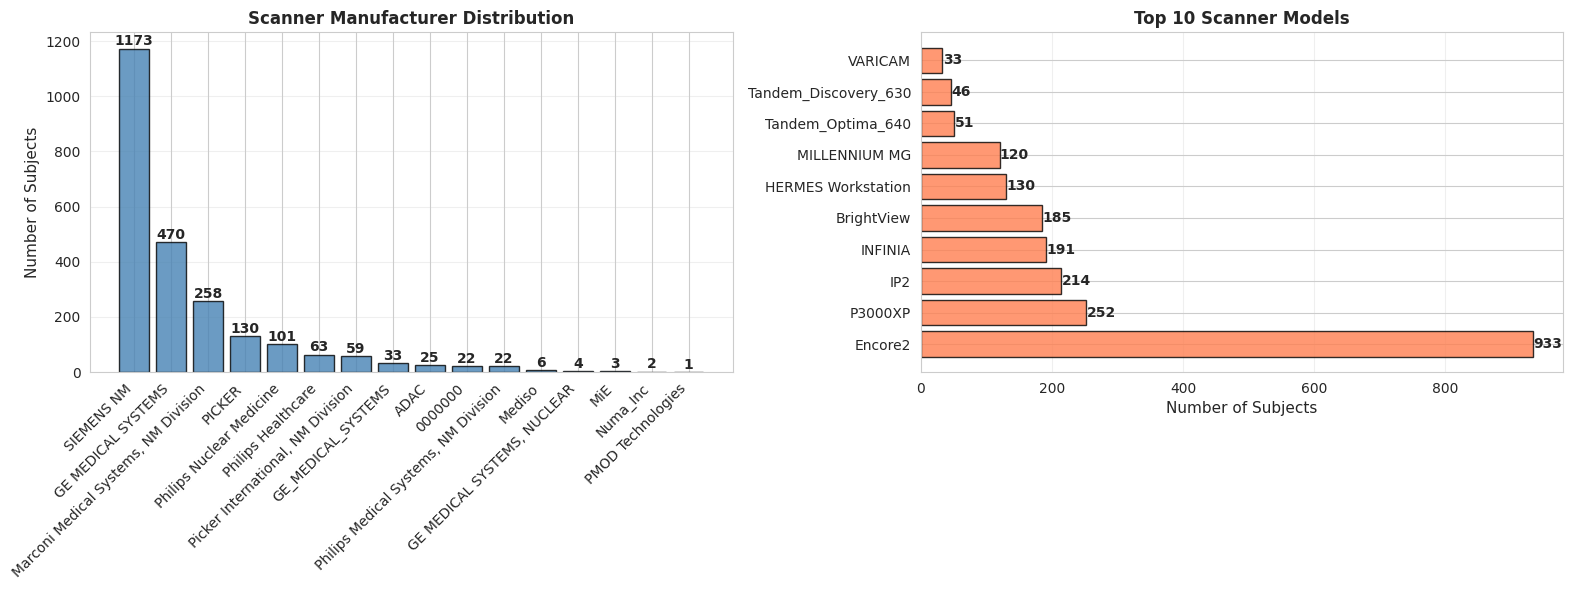

Plot saved to: output/scanner_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Manufacturer distribution
mfg_counts = df_analysis['Manufacturer'].value_counts()
axes[0].bar(range(len(mfg_counts)), mfg_counts.values, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xticks(range(len(mfg_counts)))
axes[0].set_xticklabels(mfg_counts.index, rotation=45, ha='right', fontsize=10)
axes[0].set_ylabel('Number of Subjects', fontsize=11)
axes[0].set_title('Scanner Manufacturer Distribution', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for i, v in enumerate(mfg_counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', va='bottom', fontsize=10, fontweight='bold')

# Model distribution
model_counts = df_analysis['ManufacturerModelName'].value_counts().head(10)
axes[1].barh(range(len(model_counts)), model_counts.values, color='coral', edgecolor='black', alpha=0.8)
axes[1].set_yticks(range(len(model_counts)))
axes[1].set_yticklabels(model_counts.index, fontsize=10)
axes[1].set_xlabel('Number of Subjects', fontsize=11)
axes[1].set_title('Top 10 Scanner Models', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='x')

# Add value labels
for i, v in enumerate(model_counts.values):
    axes[1].text(v + 0.5, i, str(v), va='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('output/scanner_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/scanner_distribution.png")

### 4.2 SBR Values by Manufacturer

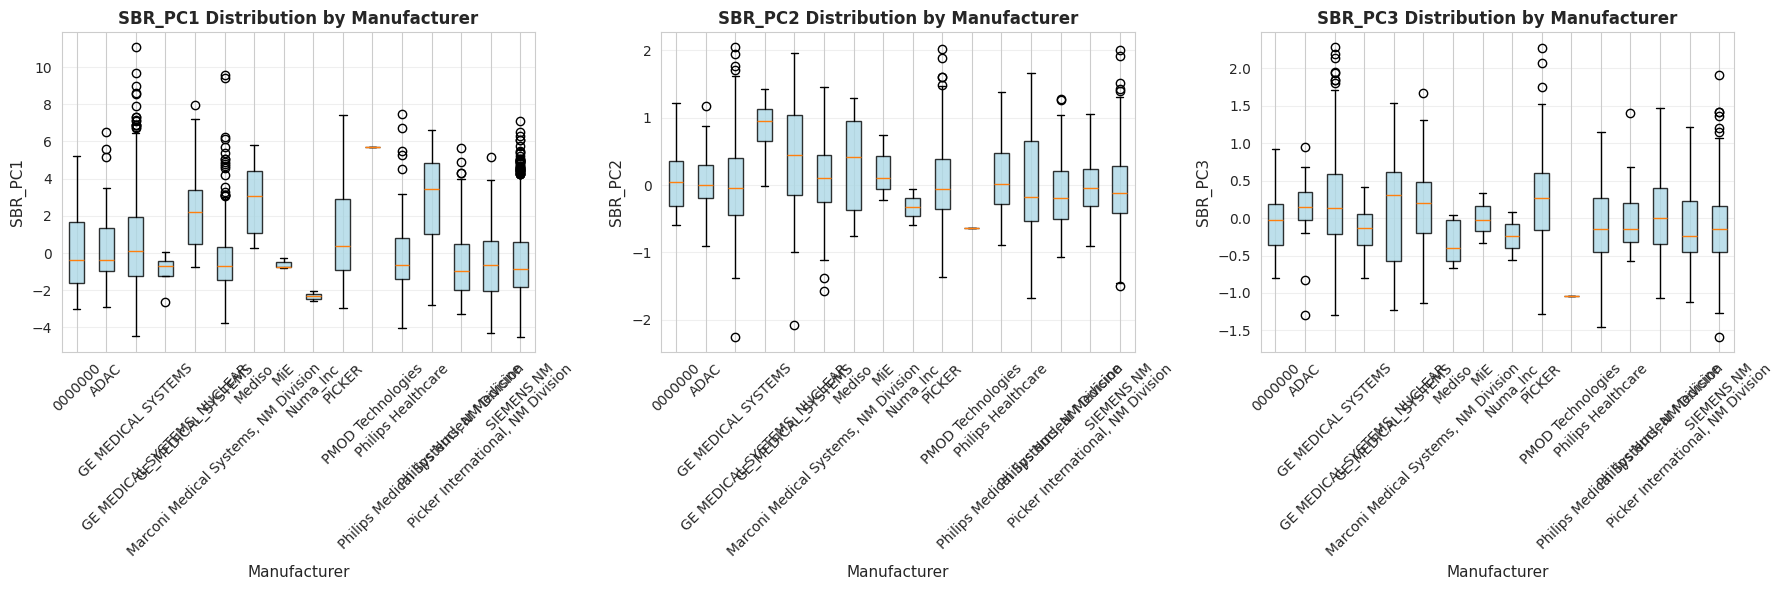

Plot saved to: output/sbr_by_manufacturer.png


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

df_plot = df_analysis.dropna(subset=['Manufacturer'])

for idx, target in enumerate(TARGETS):
    # Box plot
    manufacturers = sorted(df_plot['Manufacturer'].unique())
    data_by_mfg = [df_plot[df_plot['Manufacturer'] == mfg][target].values for mfg in manufacturers]
    
    bp = axes[idx].boxplot(data_by_mfg, labels=manufacturers, patch_artist=True)
    
    # Color boxes
    for patch in bp['boxes']:
        patch.set_facecolor('lightblue')
        patch.set_alpha(0.8)
    
    axes[idx].set_ylabel(target, fontsize=11)
    axes[idx].set_xlabel('Manufacturer', fontsize=11)
    axes[idx].set_title(f'{target} Distribution by Manufacturer', fontsize=12, fontweight='bold')
    axes[idx].grid(True, alpha=0.3, axis='y')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('output/sbr_by_manufacturer.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/sbr_by_manufacturer.png")

### 4.3 Latent Feature Distributions by Manufacturer

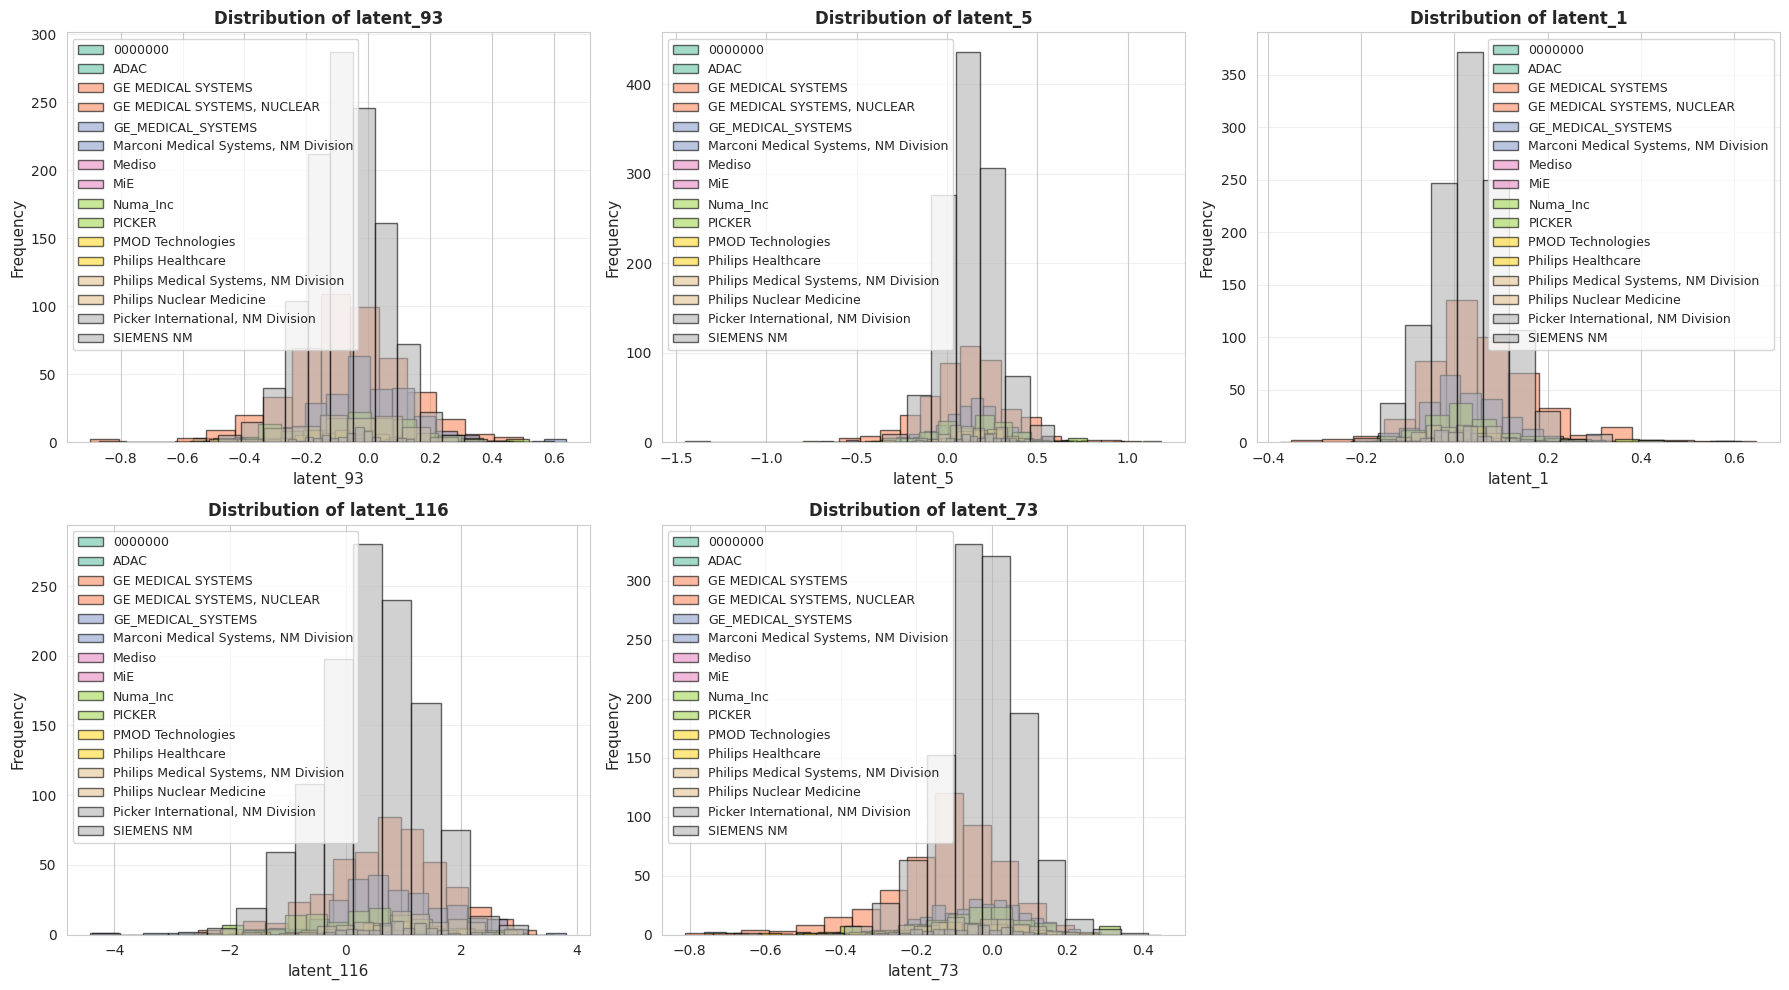

Plot saved to: output/latent_features_by_manufacturer.png


In [12]:
# Select top latent dimensions
top_dims = ['latent_93', 'latent_5', 'latent_1', 'latent_116', 'latent_73']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

df_plot = df_analysis.dropna(subset=['Manufacturer'])
manufacturers = sorted(df_plot['Manufacturer'].unique())
colors = plt.cm.Set2(np.linspace(0, 1, len(manufacturers)))

for idx, dim in enumerate(top_dims):
    for mfg_idx, mfg in enumerate(manufacturers):
        mfg_data = df_plot[df_plot['Manufacturer'] == mfg][dim].values
        axes[idx].hist(mfg_data, alpha=0.6, label=mfg, bins=15, color=colors[mfg_idx], edgecolor='black')
    
    axes[idx].set_xlabel(dim, fontsize=11)
    axes[idx].set_ylabel('Frequency', fontsize=11)
    axes[idx].set_title(f'Distribution of {dim}', fontsize=12, fontweight='bold')
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3, axis='y')

# Remove extra subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.savefig('output/latent_features_by_manufacturer.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plot saved to: output/latent_features_by_manufacturer.png")

## Section 5: Summary and Recommendations

### 5.1 Key Findings

In [13]:
print("\n" + "="*80)
print("KEY FINDINGS: DICOM METADATA ANALYSIS")
print("="*80)

print(f"\n1. SCANNER HETEROGENEITY:")
print(f"   - Number of manufacturers: {df_analysis['Manufacturer'].nunique()}")
print(f"   - Number of models: {df_analysis['ManufacturerModelName'].nunique()}")
print(f"   - Subjects with metadata: {df_analysis['Manufacturer'].notna().sum()}/{len(df_analysis)}")

print(f"\n2. MANUFACTURER DISTRIBUTION:")
for mfg, count in df_analysis['Manufacturer'].value_counts().items():
    pct = count / len(df_analysis) * 100
    print(f"   - {mfg}: {count} subjects ({pct:.1f}%)")

print(f"\n3. SCANNER EFFECTS:")
print(f"   - Check ANOVA results above for statistical significance")
print(f"   - If p<0.05: Scanner manufacturer affects SBR values")
print(f"   - If p≥0.05: No significant scanner effect detected")

print(f"\n4. RECOMMENDATIONS:")
print(f"   - If scanner effect detected: Consider harmonization")
print(f"   - If no effect: Current model is robust to scanner differences")
print(f"   - Always report scanner distribution in methods")


KEY FINDINGS: DICOM METADATA ANALYSIS

1. SCANNER HETEROGENEITY:
   - Number of manufacturers: 16
   - Number of models: 26
   - Subjects with metadata: 2372/2373

2. MANUFACTURER DISTRIBUTION:
   - SIEMENS NM: 1173 subjects (49.4%)
   - GE MEDICAL SYSTEMS: 470 subjects (19.8%)
   - Marconi Medical Systems, NM Division: 258 subjects (10.9%)
   - PICKER: 130 subjects (5.5%)
   - Philips Nuclear Medicine: 101 subjects (4.3%)
   - Philips Healthcare: 63 subjects (2.7%)
   - Picker International, NM Division: 59 subjects (2.5%)
   - GE_MEDICAL_SYSTEMS: 33 subjects (1.4%)
   - ADAC: 25 subjects (1.1%)
   - 0000000: 22 subjects (0.9%)
   - Philips Medical Systems, NM Division: 22 subjects (0.9%)
   - Mediso: 6 subjects (0.3%)
   - GE MEDICAL SYSTEMS, NUCLEAR: 4 subjects (0.2%)
   - MiE: 3 subjects (0.1%)
   - Numa_Inc: 2 subjects (0.1%)
   - PMOD Technologies: 1 subjects (0.0%)

3. SCANNER EFFECTS:
   - Check ANOVA results above for statistical significance
   - If p<0.05: Scanner manufactu

### 5.2 Save Results

In [14]:
output_dir = Path('output')

# Save scanner summary
scanner_summary_export = df_analysis[['PATNO', 'Manufacturer', 'ManufacturerModelName', 'SBR_PC1', 'SBR_PC2', 'SBR_PC3']].copy()
scanner_summary_export = scanner_summary_export.dropna(subset=['Manufacturer'])
scanner_summary_export.to_csv(output_dir / 'scanner_subject_mapping.csv', index=False)

# Save manufacturer statistics
mfg_stats = []
for mfg in df_analysis['Manufacturer'].dropna().unique():
    mfg_data = df_analysis[df_analysis['Manufacturer'] == mfg]
    mfg_stats.append({
        'Manufacturer': mfg,
        'N_Subjects': len(mfg_data),
        'SBR_PC1_Mean': mfg_data['SBR_PC1'].mean(),
        'SBR_PC1_Std': mfg_data['SBR_PC1'].std(),
        'SBR_PC2_Mean': mfg_data['SBR_PC2'].mean(),
        'SBR_PC2_Std': mfg_data['SBR_PC2'].std(),
        'SBR_PC3_Mean': mfg_data['SBR_PC3'].mean(),
        'SBR_PC3_Std': mfg_data['SBR_PC3'].std()
    })

df_mfg_stats = pd.DataFrame(mfg_stats)
df_mfg_stats.to_csv(output_dir / 'manufacturer_statistics.csv', index=False)

print("Results saved to:")
print(f"  - {output_dir / 'scanner_subject_mapping.csv'}")
print(f"  - {output_dir / 'manufacturer_statistics.csv'}")

print(f"\nManufacturer Statistics:")
print(df_mfg_stats.to_string(index=False))

Results saved to:
  - output/scanner_subject_mapping.csv
  - output/manufacturer_statistics.csv

Manufacturer Statistics:
                        Manufacturer  N_Subjects  SBR_PC1_Mean  SBR_PC1_Std  SBR_PC2_Mean  SBR_PC2_Std  SBR_PC3_Mean  SBR_PC3_Std
                          SIEMENS NM        1173     -0.373643     2.045763     -0.049582     0.515923     -0.133632     0.453109
                              PICKER         130      1.138549     2.601685      0.080982     0.654852      0.270539     0.617575
            Philips Nuclear Medicine         101     -0.533377     2.012925     -0.131736     0.513630      0.031490     0.536463
                  GE MEDICAL SYSTEMS         470      0.620546     2.586659      0.013142     0.630354      0.200585     0.617801
                  GE_MEDICAL_SYSTEMS          33      2.471206     2.373647      0.439152     0.907596      0.113078     0.799576
Marconi Medical Systems, NM Division         258     -0.315033     1.995052      0.105689     0.50